1. What is the maximum quantum volume you can achieve using a simulated Athens device?

In [2]:
from qiskit_aer import AerSimulator
from qiskit_experiments.framework import BatchExperiment
from qiskit_experiments.library import QuantumVolume
from qiskit_ibm_runtime.fake_provider import FakeAthensV2

backend_athens = FakeAthensV2() # A fake 5 qubit backend.
backend_athens_sim = AerSimulator.from_backend(backend_athens) # Use the Aer simulator to run the experiment.

In [3]:
print(f"Using backend: {backend_athens.__class__.__name__}")

qubits_count = backend_athens.configuration().num_qubits
print(f"Number of qubits: {qubits_count}")

exps = [QuantumVolume(tuple(range(i)), trials=2500) for i in range(1, qubits_count + 1)]

batch_exp = BatchExperiment(exps)
batch_exp.set_transpile_options(optimization_level=3)

batch_expdata = batch_exp.run(backend_athens_sim).block_for_results()

qv_values = batch_expdata.analysis_results("quantum_volume", dataframe=True).value.tolist()
print(f"Max quantum volume is: {max(qv_values)}")
display(batch_expdata.analysis_results("quantum_volume", dataframe=True))

Using backend: FakeAthensV2
Number of qubits: 5
Max quantum volume is: 32


,name,experiment,components,value,quality,backend,run_time,HOPs,two_sigma,depth,trials,success,confidence
d469e506,quantum_volume,QuantumVolume,[Q0],2,good,aer_simulator_from(fake_athens),None,None,None,1,2500,True,1.0
e7f06ed8,quantum_volume,QuantumVolume,"[Q0, Q1]",4,good,aer_simulator_from(fake_athens),None,None,None,2,2500,True,1.0
510fcfd8,quantum_volume,QuantumVolume,"[Q0, Q1, Q2]",8,good,aer_simulator_from(fake_athens),None,None,None,3,2500,True,1.0
aba631e7,quantum_volume,QuantumVolume,"[Q0, Q1, Q2, Q3]",16,good,aer_simulator_from(fake_athens),None,None,None,4,2500,True,0.999999
ea48f23f,quantum_volume,QuantumVolume,"[Q0, Q1, Q2, Q3, Q4]",32,good,aer_simulator_from(fake_athens),None,None,None,5,2500,True,0.989441


2. What affect does changing the list of qubits have?

💡Athens is the backend with linear topology.

🔗 Qubit connections (bonds): EdgeList[(0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4), (4, 3)]


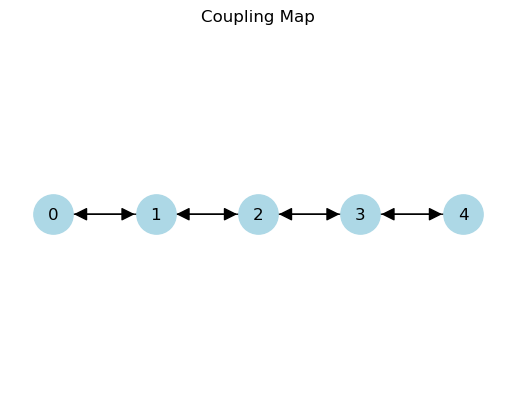

In [4]:
coupling_map = backend_athens.coupling_map.get_edges()
print("🔗 Qubit connections (bonds):", coupling_map)

# Plotting the coupling map
import matplotlib.pyplot as plt
import networkx as nx

def plot_coupling_map(coupling):
    G = nx.DiGraph()
    G.add_edges_from(coupling)
    pos = {node: (node, 0) for node in range(len(G.nodes()))}
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800)
    nx.draw_networkx_labels(G, pos, font_size=12)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>' , width=1, arrowsize=20, min_target_margin=15)
    plt.title("Coupling Map")
    plt.axis('off')
    plt.show()

plot_coupling_map(coupling_map)

If the qubits aren't fully connect, transpilation adds SWAP gates, which adds more noise.

So we are going to test with 

- q0-q1 => fully connect
- q1-q3 => not connect

In [6]:
exps_swaptest = []

exps_swaptest.append(QuantumVolume(physical_qubits=[0, 1], seed=106, trials=200))
exps_swaptest.append(QuantumVolume(physical_qubits=[1, 3], seed=106, trials=200))


batch_exp_swaptest = BatchExperiment(exps_swaptest)
batch_exp_swaptest.set_transpile_options(optimization_level=3)

batch_exp_data_swaptest = batch_exp_swaptest.run(backend_athens_sim).block_for_results()
qv_values_swaptest = batch_exp_data_swaptest.analysis_results(dataframe=True)

display(qv_values_swaptest)


,name,experiment,components,value,quality,backend,run_time,HOPs,two_sigma,depth,trials,success,confidence
780e5950,mean_HOP,QuantumVolume,"[Q0, Q1]",0.765+/-0.030,good,aer_simulator_from(fake_athens),None,"[0.7744140625, 0.7099609375, 0.6962890625, 0.6...",0.059948,2,200,None,None
22f2fd9d,quantum_volume,QuantumVolume,"[Q0, Q1]",4,good,aer_simulator_from(fake_athens),None,None,None,2,200,True,0.999492
88924917,mean_HOP,QuantumVolume,"[Q1, Q3]",0.746+/-0.031,good,aer_simulator_from(fake_athens),None,"[0.7255859375, 0.66796875, 0.701171875, 0.6572...",0.061583,2,200,None,None
1532e53a,quantum_volume,QuantumVolume,"[Q1, Q3]",4,good,aer_simulator_from(fake_athens),None,None,None,2,200,True,0.994875



Component experiment 0


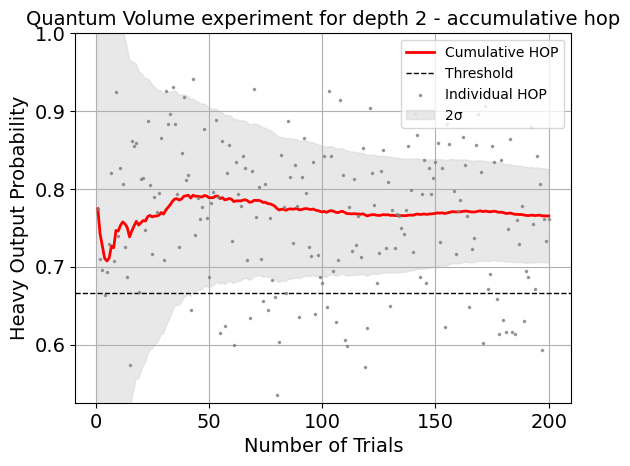


Component experiment 1


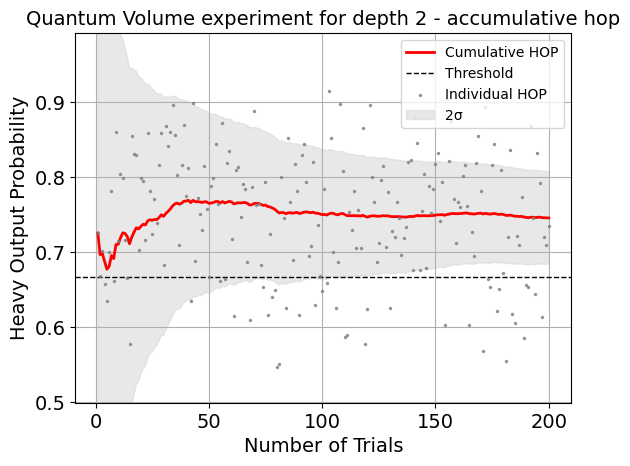

In [14]:
for i in range(batch_exp_swaptest.num_experiments):
    print(f"\nComponent experiment {i}")
    display(batch_exp_data_swaptest.figure(i))

- q0-q1 could get the HOP value more than q1-q3 which means it is more stable
- the confidence level of q0-q1 also more than q1-q3 which is more reliable
- 2σ of q0-q1 is lower than q1-q3 which is less noisy

How about change the size of qubits list ...

In [8]:
exps_sizetest = []

exps_sizetest.append(QuantumVolume(physical_qubits=[0, 1], seed=106, trials=600))
exps_sizetest.append(QuantumVolume(physical_qubits=[0, 1, 2], seed=106, trials=600))
exps_sizetest.append(QuantumVolume(physical_qubits=[0, 1, 2, 3], seed=106, trials=600))

batch_exp_sizetest = BatchExperiment(exps_sizetest)
batch_exp_sizetest.set_transpile_options(optimization_level=3)

batch_exp_data_sizetest = batch_exp_sizetest.run(backend_athens_sim).block_for_results()
qv_values_sizetest = batch_exp_data_sizetest.analysis_results(dataframe=True)

display(qv_values_sizetest)


,name,experiment,components,value,quality,backend,run_time,HOPs,two_sigma,depth,trials,success,confidence
ff8421b3,mean_HOP,QuantumVolume,"[Q0, Q1]",0.768+/-0.017,good,aer_simulator_from(fake_athens),None,"[0.779296875, 0.701171875, 0.677734375, 0.6591...",0.034455,2,600,None,None
dba921a7,quantum_volume,QuantumVolume,"[Q0, Q1]",4,good,aer_simulator_from(fake_athens),None,None,None,2,600,True,1.0
9005ae97,mean_HOP,QuantumVolume,"[Q0, Q1, Q2]",0.807+/-0.016,good,aer_simulator_from(fake_athens),None,"[0.798828125, 0.8115234375, 0.9033203125, 0.85...",0.032215,3,600,None,None
6e7f80ae,quantum_volume,QuantumVolume,"[Q0, Q1, Q2]",8,good,aer_simulator_from(fake_athens),None,None,None,3,600,True,1.0
0f3dd24b,mean_HOP,QuantumVolume,"[Q0, Q1, Q2, Q3]",0.709+/-0.019,good,aer_simulator_from(fake_athens),None,"[0.646484375, 0.6328125, 0.72265625, 0.6416015...",0.037076,4,600,None,None
d83b6edf,quantum_volume,QuantumVolume,"[Q0, Q1, Q2, Q3]",16,good,aer_simulator_from(fake_athens),None,None,None,4,600,True,0.989247



Component experiment 0


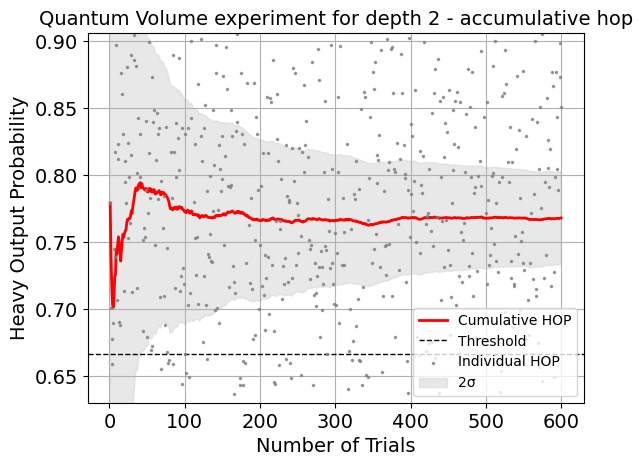


Component experiment 1


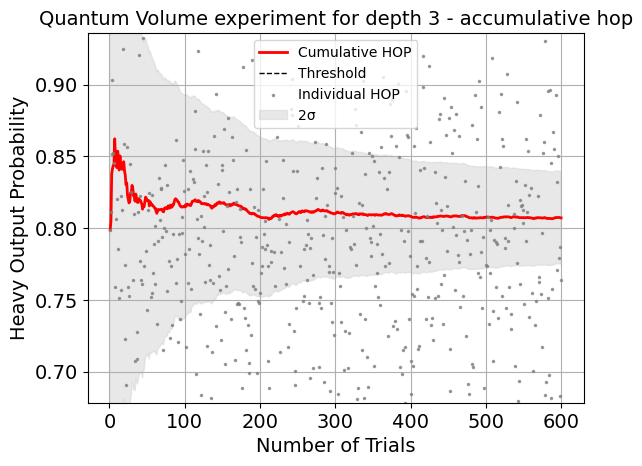


Component experiment 2


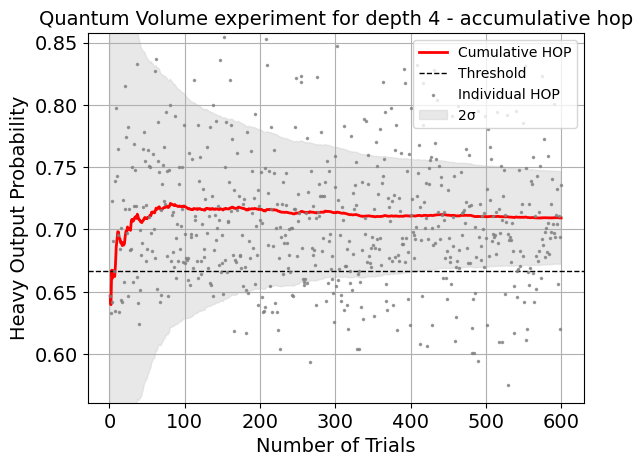

In [13]:
for i in range(batch_exp_sizetest.num_experiments):
    print(f"\nComponent experiment {i}")
    display(batch_exp_data_sizetest.figure(i))

- The expected qv will increase => like $2^n$. As the experiment above, the QV value are increase when the more qubits used. On the other hand, it could perform as the QV value not equal to the expected value, too. But not appear in the above experiment.
- The confidence may decrease because complexity made the less reliability.

3. What affect does changing the optimization level have?

In [20]:
exps_optest = []

for level in range(0, 4):
    qv = QuantumVolume(physical_qubits=[0, 4, 2], seed=106, trials=250)
    qv.set_transpile_options(optimization_level=level)
    exps_optest.append(qv)

batch_exp_optest = BatchExperiment(exps_optest)
batch_exp_data_optest = batch_exp_optest.run(backend_athens_sim).block_for_results()
qv_values_optest = batch_exp_data_optest.analysis_results(dataframe=True)
display(qv_values_optest)

,name,experiment,components,value,quality,backend,run_time,HOPs,two_sigma,depth,trials,success,confidence
5203f916,mean_HOP,QuantumVolume,"[Q0, Q4, Q2]",0.778+/-0.026,good,aer_simulator_from(fake_athens),None,"[0.75, 0.7978515625, 0.86328125, 0.7861328125,...",0.052536,3,250,None,None
c8b72577,quantum_volume,QuantumVolume,"[Q0, Q4, Q2]",8,good,aer_simulator_from(fake_athens),None,None,None,3,250,True,0.999989
88c016ec,mean_HOP,QuantumVolume,"[Q0, Q4, Q2]",0.779+/-0.026,good,aer_simulator_from(fake_athens),None,"[0.7451171875, 0.791015625, 0.8408203125, 0.80...",0.052484,3,250,None,None
38bf6f16,quantum_volume,QuantumVolume,"[Q0, Q4, Q2]",8,good,aer_simulator_from(fake_athens),None,None,None,3,250,True,0.999991
c6ce7820,mean_HOP,QuantumVolume,"[Q0, Q4, Q2]",0.789+/-0.026,good,aer_simulator_from(fake_athens),None,"[0.74609375, 0.783203125, 0.8486328125, 0.8007...",0.051644,3,250,None,None
fb4e973f,quantum_volume,QuantumVolume,"[Q0, Q4, Q2]",8,good,aer_simulator_from(fake_athens),None,None,None,3,250,True,0.999999
8fca8d1d,mean_HOP,QuantumVolume,"[Q0, Q4, Q2]",0.788+/-0.026,good,aer_simulator_from(fake_athens),None,"[0.7373046875, 0.8076171875, 0.6455078125, 0.7...",0.05168,3,250,None,None
c63b34ec,quantum_volume,QuantumVolume,"[Q0, Q4, Q2]",8,good,aer_simulator_from(fake_athens),None,None,None,3,250,True,0.999999



Component experiment 0


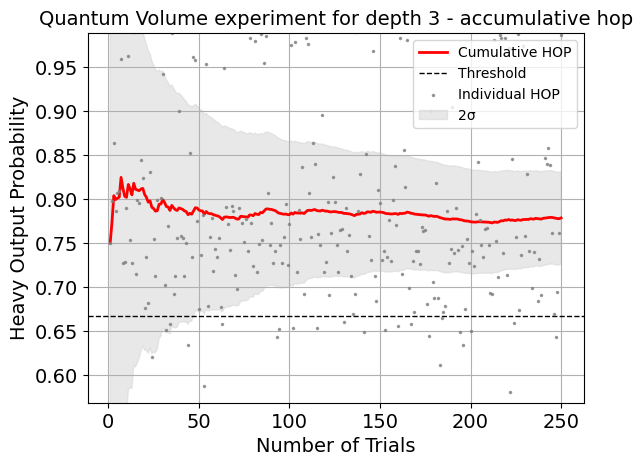


Component experiment 1


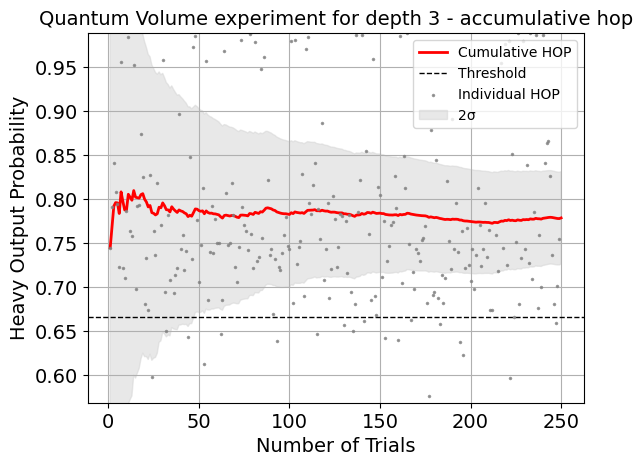


Component experiment 2


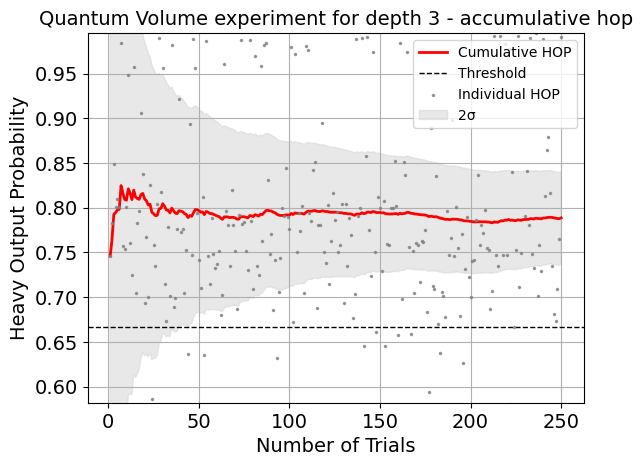


Component experiment 3


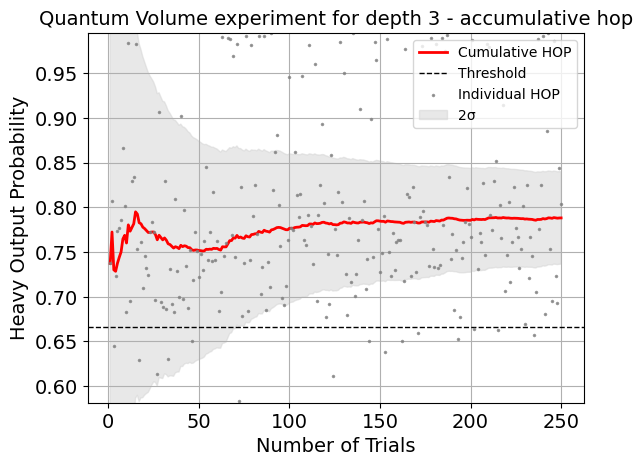

In [22]:
for i in range(batch_exp_optest.num_experiments):
    print(f"\nComponent experiment {i}")
    display(batch_exp_data_optest.figure(i))

The confidence value increases when use greater optimise level. Since the greater optimise level means the more simplify the circuit to fit the backend, it might gain the more reliability.

4. Can you do anything to improve the score?

Since the experiment above get the maximum score (QV is $2^n$) in all case. So it could not get any higher score. But if the score is below the maximum score, I would improve by change the optimization level and the seed. Because QV uses the random circuit, some circuit might fit the backend more. The qubits sequence and number of the qubits used for test must be consider, too. If using lots of qubit, it will be more complex and must use increase trial to test. When the trial is less, the confidence value will decrease and the QV value might below than the expected result.

In the other case that backend is created by as, changed the topology is one of case should be try. From the knowledge that the complexity of the topology could made the more coupling of each qubits, if the backend is not full mesh, it could add more coupling to each node. This could make the QV score increase cause more coupling could fit the circuit more easily and reduce the noise created from the traspile method.